# Lux API example ⚡️

This notebook demonstrates the high-level `LuxModel` API (`src/lux_model.py`), which wraps
the lower-level routines (`init_latents`, `optimise`, `scatters`) into a single model object:

1. generate a synthetic dataset of spectra + noisy labels from the Lux generative process,
2. **train** the model latents (`fit`),
3. **predict labels from spectra** for held-out stars (`predict_labels`),
4. **predict spectra from labels** (`predict_fluxes`),
5. inspect the latent space, and
6. save / load the trained model.

Everything here is synthetic, so the notebook runs without any FITS files. With real data,
replace the data-generation cell with `load_data.load_data(...)` and proceed identically.

In [1]:
import sys
from pathlib import Path
SRC = Path('/home/100/mj8805/scr_mk27/Lux')
sys.path.append(SRC / 'src')

import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

from lux_model import LuxModel

plt.rcParams['figure.dpi'] = 110

## 1. Synthetic data

We draw stars from the model's own generative process: a latent vector $\zeta_n$ per star
(dimension 0 is the continuum, fixed at one; the rest drive the physics), labels that are
affine in the latents ($T_\mathrm{eff}$, $\log g$, $\mathrm{[Fe/H]}$), and spectra built
from a flat continuum plus absorption lines whose depths respond linearly to the latents.
Both labels and fluxes get Gaussian noise at their quoted errors.

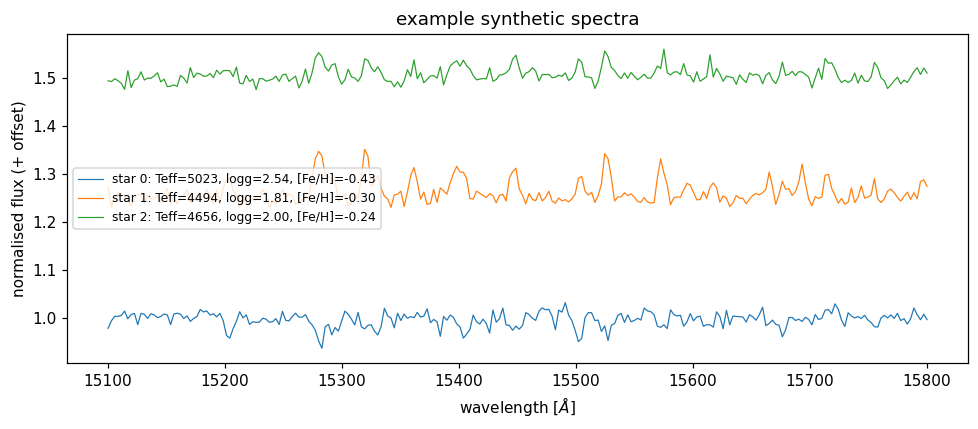

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
for i, offset in zip(range(3), [0., 0.25, 0.5]):
    ax.plot(wl, fluxes[i] + offset, lw=0.8,
            label=f'star {i}: Teff={labels[i, 0]:.0f}, logg={labels[i, 1]:.2f}, [Fe/H]={labels[i, 2]:.2f}')
ax.set_xlabel('wavelength [$\AA$]')
ax.set_ylabel('normalised flux (+ offset)')
ax.legend(fontsize=8)
ax.set_title('example synthetic spectra')
plt.tight_layout()

## 2. Train the model

`fit` initialises the latents (`init_latents`), runs the un-regularised alpha/beta/zeta
coordinate-descent agenda (`optimise.run_agenda`) for `n_iterations`, then by default the
regularised agenda that also fits per-pixel noise scatters (`scatters.run_agenda`).

The latent dimensionality must satisfy `P >= M + 1` (one continuum dimension plus one per
label); here we use the true `P = 4`. On real data, choose `P` by cross-validation —
see `kfold_cv.py` / `run_kfold.py`.

In [4]:
model = LuxModel(P=4)
model.fit(labels[train], labels_err[train], fluxes[train], fluxes_err[train],
          n_iterations=5, l2_reg_strength=1.0, label_names=label_names)

iteration 1/5: chi2 = 59200.1434 (improvement 9586.5369)
iteration 2/5: chi2 = 59114.4773 (improvement 1.0876)
iteration 3/5: chi2 = 59114.4612 (improvement 0.0003)
iteration 4/5: chi2 = 59114.4612 (improvement 0.0000)
iteration 5/5: chi2 = 59114.4612 (improvement 0.0000)
scatter fit: negative log-likelihood = -246259.7719


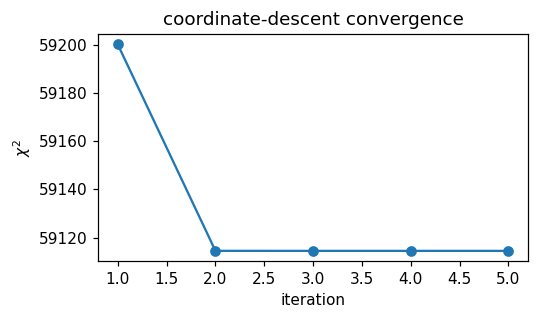

In [5]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(np.arange(1, len(model.chi2_history) + 1), model.chi2_history, 'o-')
ax.set_xlabel('iteration')
ax.set_ylabel('$\chi^2$')
ax.set_title('coordinate-descent convergence')
plt.tight_layout()

## 3. Predict labels from spectra

For new stars we first infer their latent $\zeta$ from the spectrum alone (holding the
trained betas and pixel scatters fixed), then synthesise labels as $\zeta \alpha^T$.
`predict_labels` does both steps; `return_zetas=True` also returns the latents.

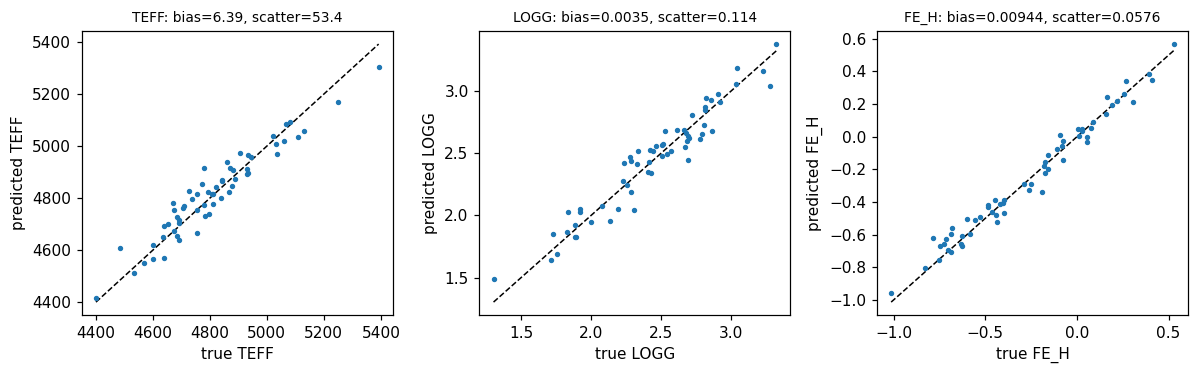

In [6]:
labels_pred, zetas_test = model.predict_labels(fluxes[test], fluxes_err[test],
                                               return_zetas=True)
labels_pred = np.asarray(labels_pred)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for m, (ax, name) in enumerate(zip(axes, label_names)):
    truth, pred = labels[test, m], labels_pred[:, m]
    lims = [truth.min(), truth.max()]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.plot(truth, pred, '.', ms=5)
    bias, scatter = np.mean(pred - truth), np.std(pred - truth)
    ax.set_title(f'{name}: bias={bias:.3g}, scatter={scatter:.3g}', fontsize=9)
    ax.set_xlabel(f'true {name}')
    ax.set_ylabel(f'predicted {name}')
plt.tight_layout()

The prediction scatter should be comparable to (or below) the quoted label errors
(50 K, 0.1 dex, 0.05 dex) — the spectra constrain the latents more tightly than the
noisy labels do.

## 4. Predict spectra from labels

The reverse direction: infer $\zeta$ from the labels alone, then synthesise the spectrum
as $\zeta \beta^T$. With `P > M` this inference is under-determined, so by default
`predict_fluxes` uses a MAP estimate with an empirical Gaussian prior built from the
training zetas, which keeps the unconstrained latent directions at typical training values
(`use_prior=False` recovers the original unregularised behaviour).

flux prediction rms over the test set: 0.0107 (flux error is 0.01)


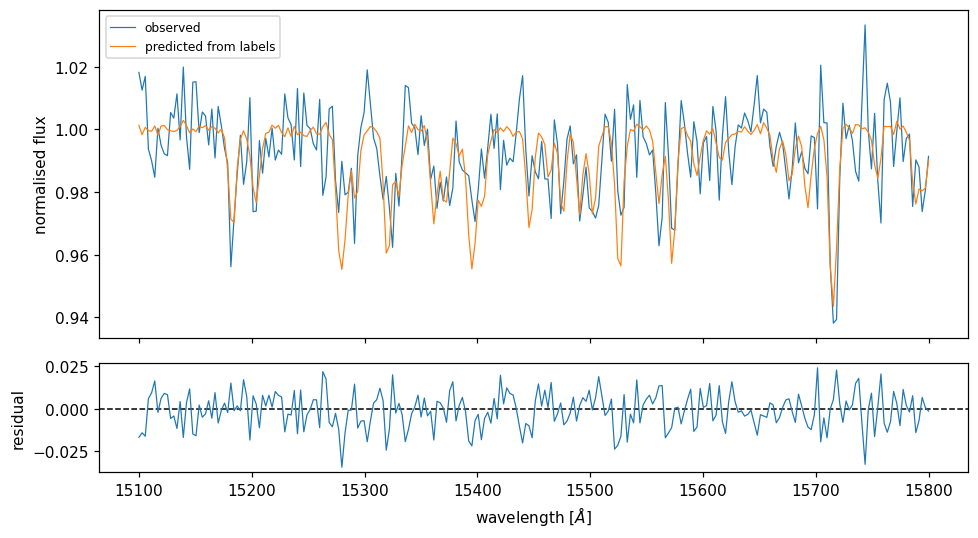

In [7]:
fluxes_pred = np.asarray(model.predict_fluxes(labels[test], labels_err[test]))

star = 5  # a test star to look at
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
axes[0].plot(wl, fluxes[test][star], lw=0.8, label='observed')
axes[0].plot(wl, fluxes_pred[star], lw=0.8, label='predicted from labels')
axes[0].set_ylabel('normalised flux')
axes[0].legend(fontsize=8)
axes[1].axhline(0., color='k', ls='--', lw=1)
axes[1].plot(wl, fluxes_pred[star] - fluxes[test][star], lw=0.8)
axes[1].set_xlabel('wavelength [$\AA$]')
axes[1].set_ylabel('residual')
plt.tight_layout()

rms = np.sqrt(np.mean((fluxes_pred - fluxes[test])**2))
print(f'flux prediction rms over the test set: {rms:.4f} (flux error is 0.01)')

## 5. The latent space

The training zetas are the per-star latent vectors the model has learned. The latent basis
is only defined up to a linear transformation, but label-correlated structure is easy to see —
here we colour two latent dimensions by [Fe/H].

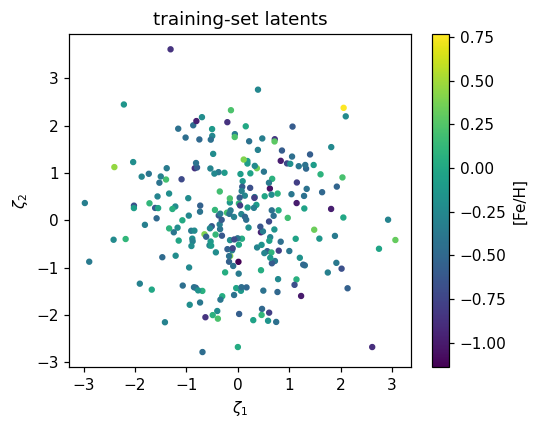

In [8]:
zetas_train = np.asarray(model.zetas)

fig, ax = plt.subplots(figsize=(5, 4))
sc = ax.scatter(zetas_train[:, 1], zetas_train[:, 2], c=labels[train, 2],
                s=10, cmap='viridis')
fig.colorbar(sc, ax=ax, label='[Fe/H]')
ax.set_xlabel('$\zeta_1$')
ax.set_ylabel('$\zeta_2$')
ax.set_title('training-set latents')
plt.tight_layout()

## 6. Save and load

`save` stores the hyperparameters, latents, scatters, and label names as a dill pickle;
`LuxModel.load` restores a model that predicts identically.

In [9]:
path = model.save('lux-example-model.dill')
restored = LuxModel.load(path)

labels_pred_restored = np.asarray(restored.predict_labels(fluxes[test], fluxes_err[test]))
assert np.allclose(labels_pred, labels_pred_restored)
print(f'saved to {path}; restored model predicts identically '
      f'(P={restored.P}, labels={restored.label_names})')

saved to lux-example-model.dill; restored model predicts identically (P=4, labels=['TEFF', 'LOGG', 'FE_H'])
